<a href="https://colab.research.google.com/github/Dongjin-1203/codeit_mission/blob/main/%EB%AF%B8%EC%85%983_2%ED%8C%80_%EC%A7%80%EB%8F%99%EC%A7%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# __스프린트 미션3(자전거 대여 대이터 분석)__

## 주제: 총 이용건수에 영향을 주는 요인을 분석하자.

# 데이터 불러오기, 데이터 확인

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/codeit/data/미션3/train.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
# 날짜데이터 파생변수로 분리
df['year'] = df.datetime.apply(lambda x : x.year)
df['month'] = df.datetime.apply(lambda x : x.month)
df['day'] = df.datetime.apply(lambda x : x.day)
df['hour'] = df.datetime.apply(lambda x : x.hour)
df['dayofweek'] = df['datetime'].dt.dayofweek
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int64         
 13  month       10886 non-null  int64         
 14  day         10886 non-null  int64         
 15  hour        10886 non-null  int64         
 16  dayofweek   10886 non-

결측값은 없다,

컬럼명    |  데이터 타입    |                            설명

datetime    datetime    자전거 대여 기록의 날짜 및 시간. 예시: 2011-01-01 00:00:00

season             int        계절 (1: 봄, 2: 여름, 3: 가을, 4: 겨울)

holiday             int        공휴일 여부 (0: 평일, 1: 공휴일)

workingday         int        근무일 여부 (0: 주말/공휴일, 1: 근무일)

weather         int        날씨 상황 (1: 맑음, 2: 구름낌/안개, 3: 약간의 비/눈, 4: 폭우/폭설)

temp               float        실측 온도 (섭씨)

atemp               float        체감 온도 (섭씨)

humidity         int        습도 (%)

windspeed       float        풍속 (m/s)

casual                 int        등록되지 않은 사용자의 대여 수

registered         int        등록된 사용자의 대여 수

count                 int        총 대여 수 (종속 변수)

casual, registered를 더한 것이 count이다 제거하자.

In [ ]:
df = df.drop(['datetime', 'casual', 'registered'], axis=1)

# 상관계수 확인

In [ ]:
df = df[['year', 'month', 'day', 'hour', 'dayofweek', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'count']]

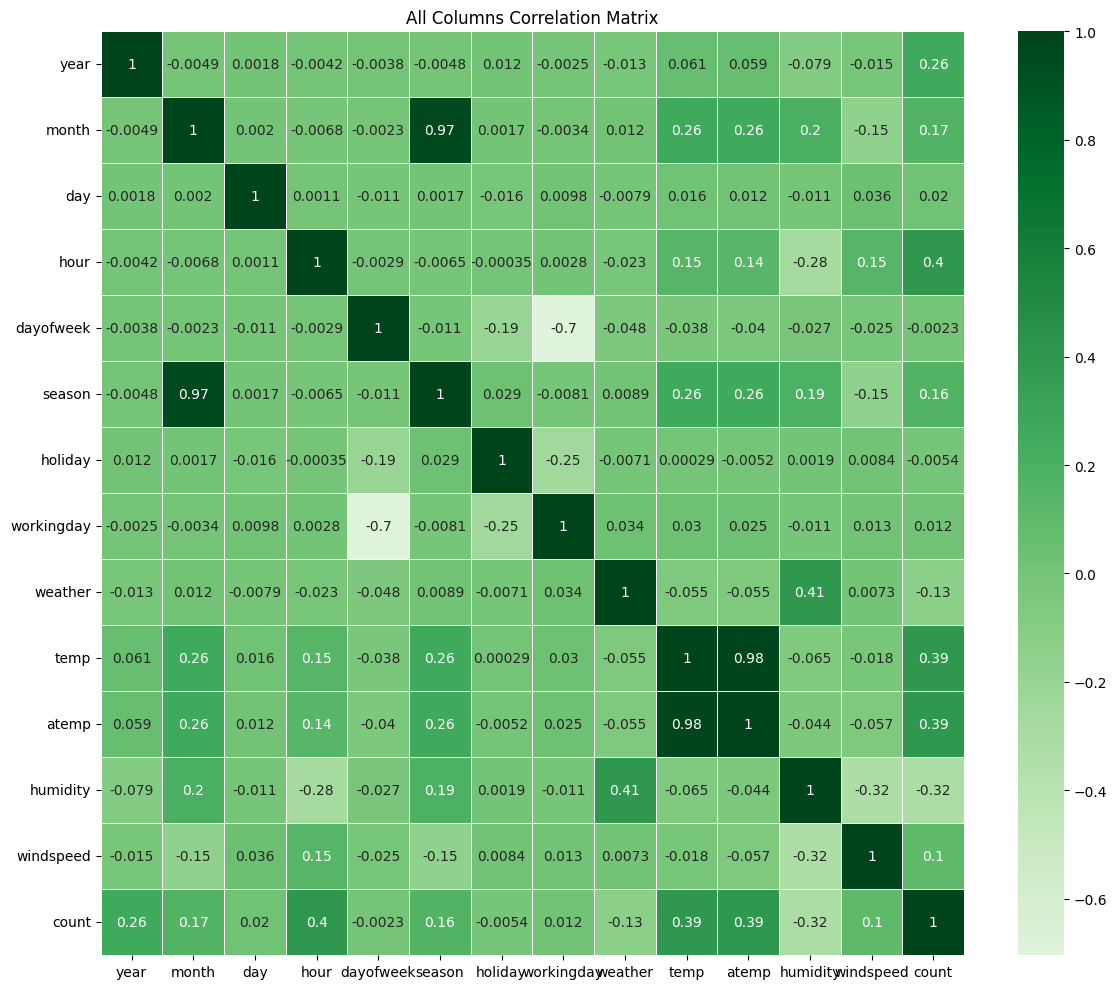

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2) 상관행렬 계산
corr_matrix = df.corr()

# 3) 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            cmap='Greens',
            annot=True,
            center=0,
            linewidths=0.5)       # 셀 경계선
plt.title('All Columns Correlation Matrix')
plt.xticks(rotation=360)
plt.yticks(rotation=360)
plt.tight_layout()
plt.show()

현재 target(count)와 강한 양의 상관관계를 띄는 데이터들이다.
 - hour(시간)
 - temp(실측 섭씨온도)
 - atemp(체감 섭씨온도)

약한 음의 상관관계이다.

 - humidity(습도)

다음은 명목형 변수들이다.

 - season(계절)
 - holiday(공휴일)
 - workingday(평일)
 - weather(날씨)

## 세부 데이터 확인

온도 습도의 분포를 확인해보자.

In [ ]:
df['atemp'].value_counts()

,count
atemp,
31.060,671
25.760,423
22.725,406
20.455,400
26.515,395
16.665,381
25.000,365
33.335,364
21.210,356


0~45도 까지 다양하다

In [ ]:
df['temp'].value_counts()

,count
temp,
14.76,467
26.24,453
28.70,427
13.94,413
18.86,406
22.14,403
25.42,403
16.40,400
22.96,395


atemp의 경우와 비슷하나 조금 온도가 낮다

In [ ]:
df['humidity'].value_counts()

,count
humidity,
88,368
94,324
83,316
87,289
70,259
...,...
8,1
13,1
97,1


In [ ]:
df['humidity'].unique()

array([ 81,  80,  75,  86,  76,  77,  72,  82,  88,  87,  94, 100,  71,
        66,  57,  46,  42,  39,  44,  47,  50,  43,  40,  35,  30,  32,
        64,  69,  55,  59,  63,  68,  74,  51,  56,  52,  49,  48,  37,
        33,  28,  38,  36,  93,  29,  53,  34,  54,  41,  45,  92,  62,
        58,  61,  60,  65,  70,  27,  25,  26,  31,  73,  21,  24,  23,
        22,  19,  15,  67,  10,   8,  12,  14,  13,  17,  16,  18,  20,
        85,   0,  83,  84,  78,  79,  89,  97,  90,  96,  91])

0, 100%가 있다. 이상한값일 수 있을 것 같다.

데이터 분포 확인

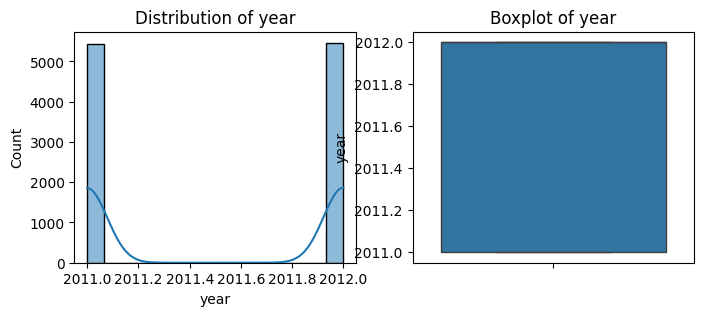

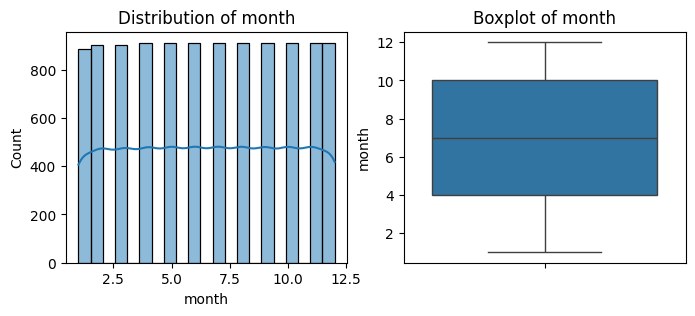

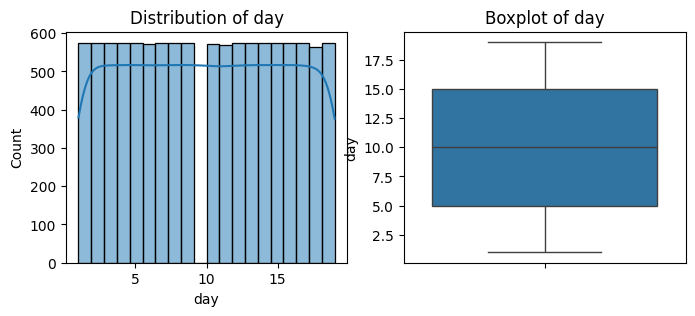

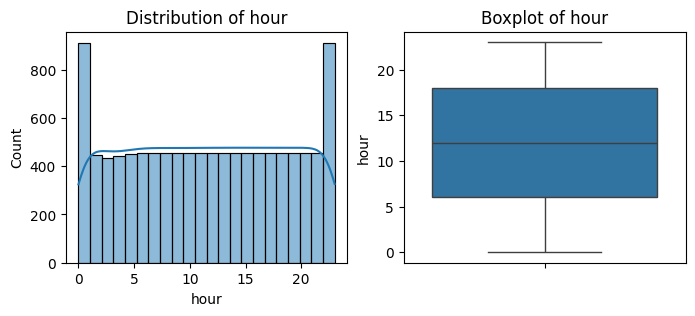

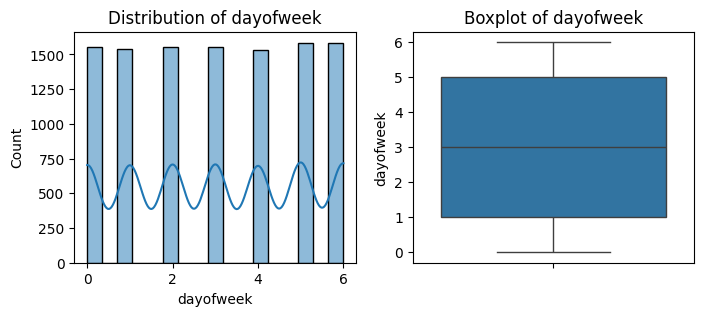

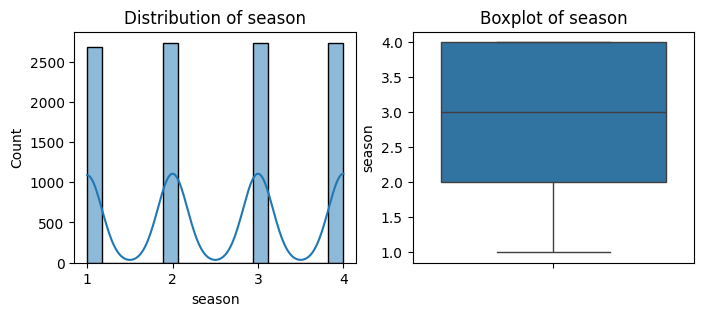

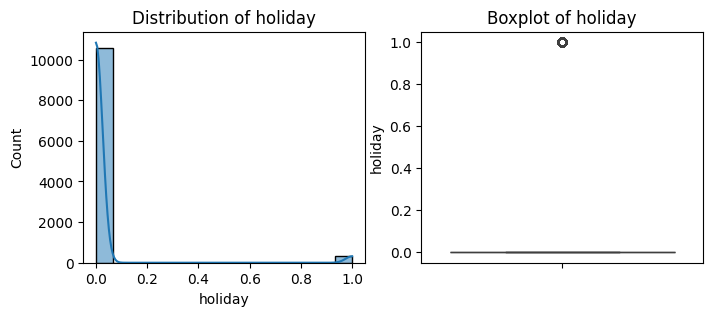

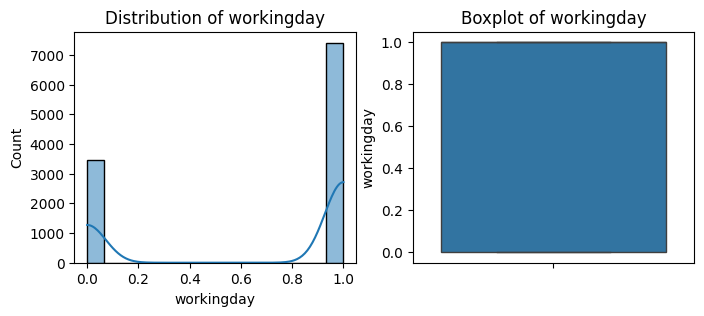

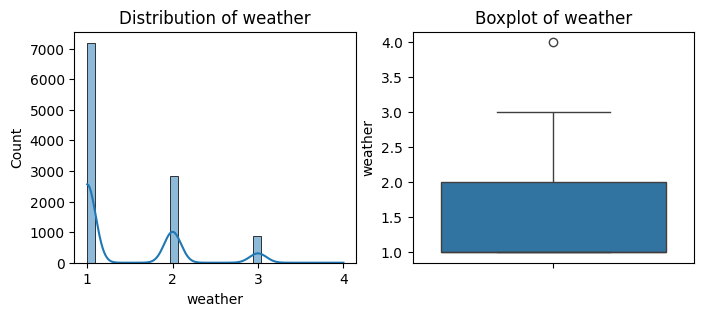

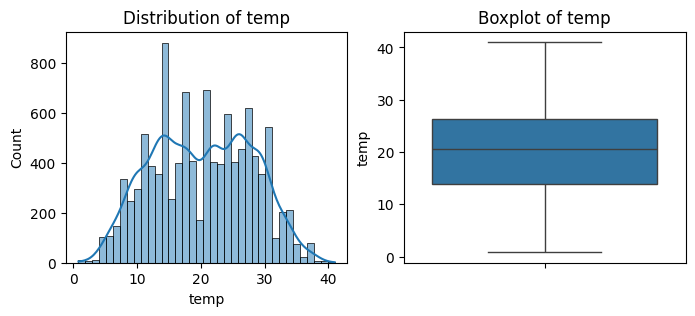

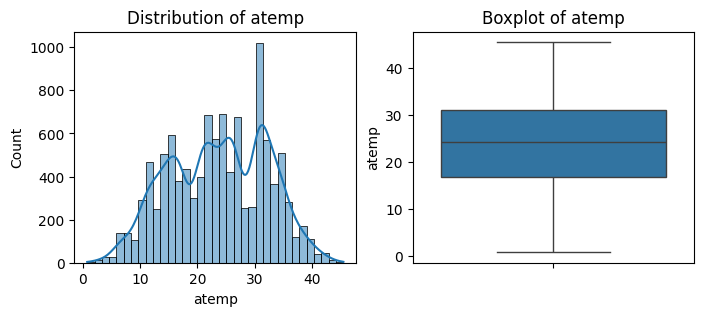

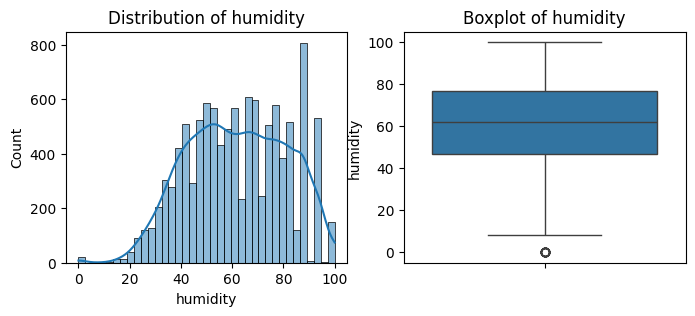

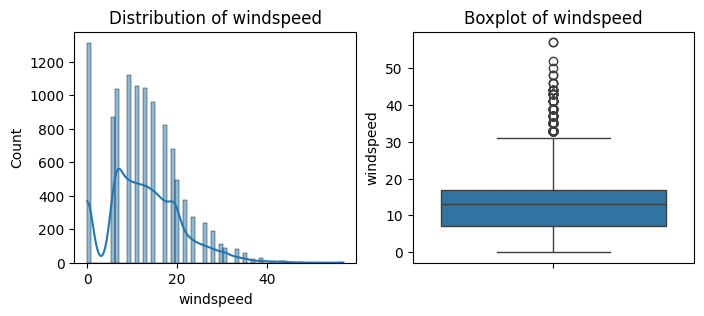

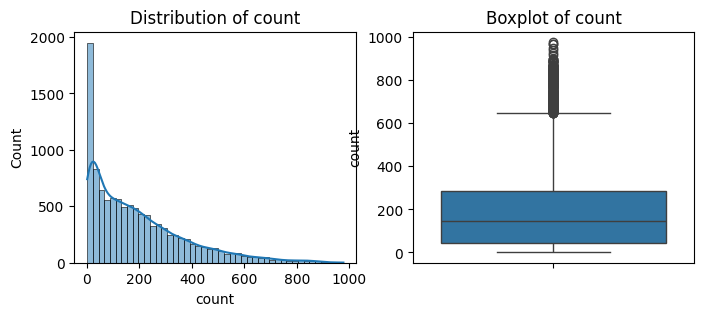

In [ ]:
# 데이터 분포
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
# numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()[:-1]    # target 빼고

for feature in numerical_features:
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature], kde=True)
    plt.title('Distribution of ' + feature)
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[feature])
    plt.title('Boxplot of ' + feature)
    plt.show()

count는 왜도를 띄는 모습이다.

windspeed에서 극단값이 많이 목격되었다.

count 데이터 분포

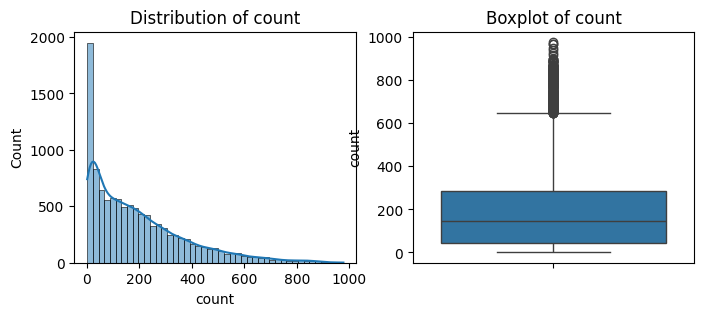

In [ ]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
sns.histplot(df['count'], kde=True)
plt.title('Distribution of count')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['count'])
plt.title('Boxplot of count')
plt.show()

windspeed의 데이터 분포

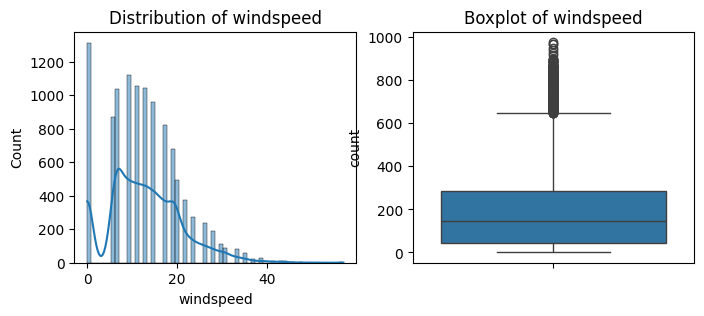

In [ ]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
sns.histplot(df['windspeed'], kde=True)
plt.title('Distribution of windspeed')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['count'])
plt.title('Boxplot of windspeed')
plt.show()

0에 몰려있는 이유를 모르겠다. 정보가 없어 결측치 처리를 한 것인가?

/tmp/ipython-input-16-2210322623.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # ← 중요!


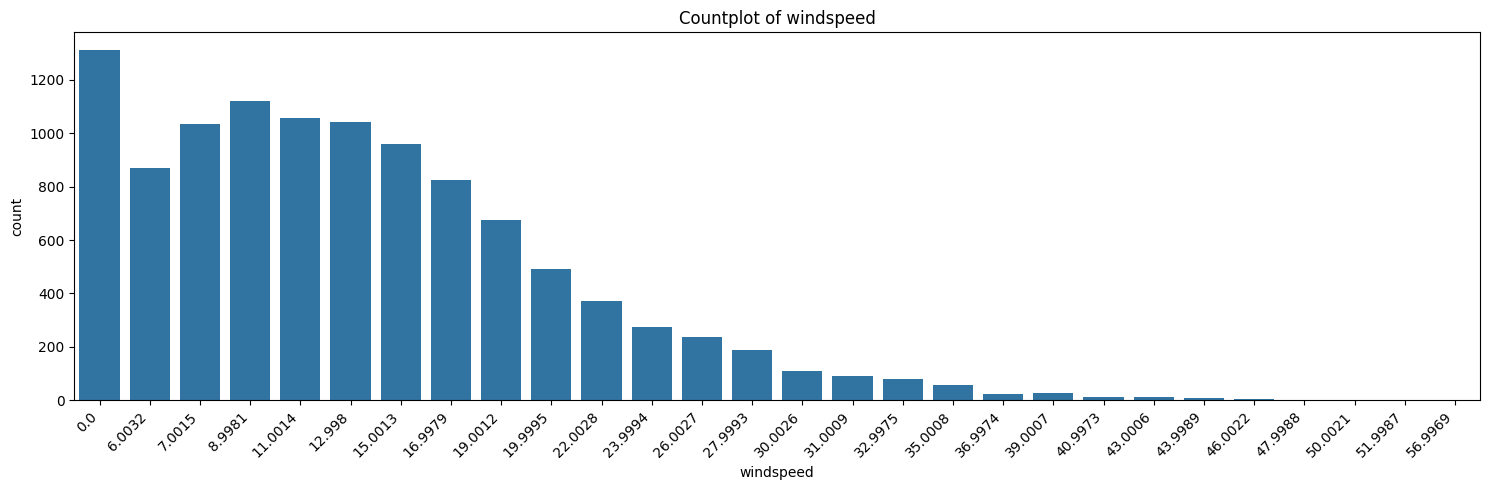

In [ ]:
# windspeed 확인
plt.figure(figsize=(15, 5))
ax = sns.countplot(data=df, x='windspeed')
plt.title('Countplot of windspeed')

# x축 라벨 회전
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # ← 중요!
plt.tight_layout()
plt.show()

0인 값은 제거해도 될 것같다. 혹시 모르니 초기 모델 평가 이후 판단해보자.

### 월벌 자전거 이용객 수

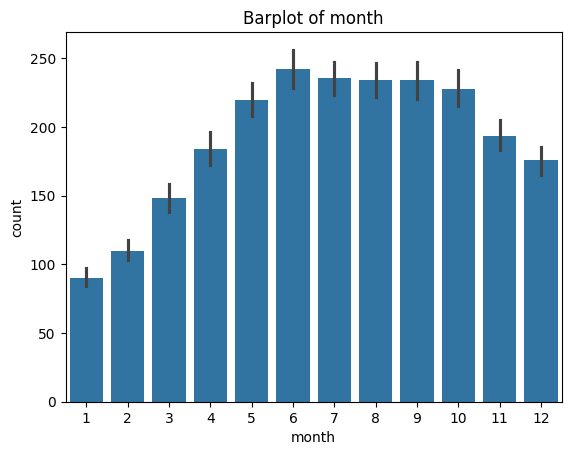

In [ ]:
sns.barplot(data = df, x='month', y='count')
plt.title('Barplot of month')
plt.show()

날이추운 1-3월은 자전거 이용수가 낮다

### 일별 자전거 이용객 수

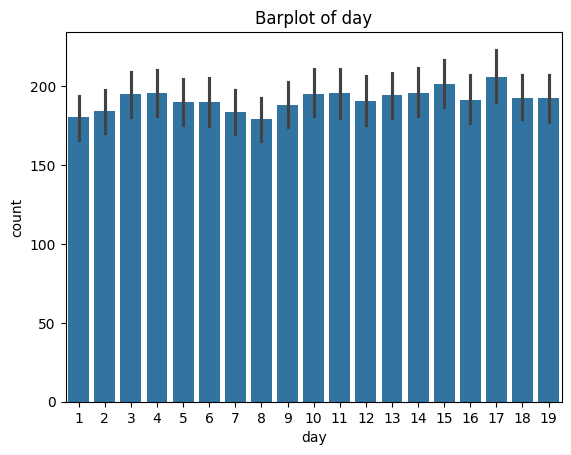

In [ ]:
sns.barplot(data = df, x='day', y='count')
plt.title('Barplot of day')
plt.show()

일별로는 큰 차이가 없다

### 계절별 자전거 이용객 수

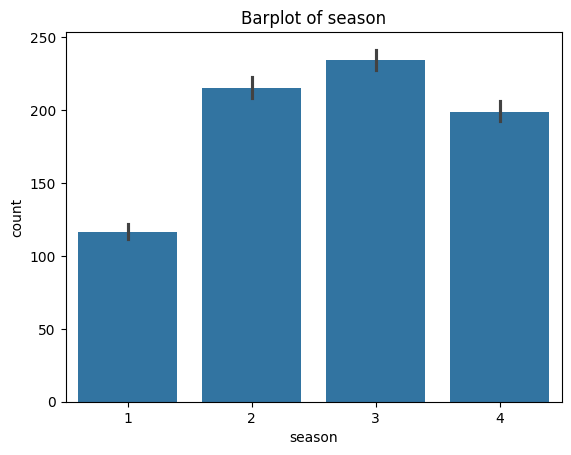

In [ ]:
sns.barplot(data = df, x='season', y='count')
plt.title('Barplot of season')
plt.show()

여름(2), 가을(3)에 이용객이 많았다

In [ ]:
# 요일 분할 기준확인용
pd.crosstab(df['season'], df['month'])

month,1,2,3,4,5,6,7,8,9,10,11,12
season,,,,,,,,,,,,
1,884,901,901,0,0,0,0,0,0,0,0,0
2,0,0,0,909,912,912,0,0,0,0,0,0
3,0,0,0,0,0,0,912,912,909,0,0,0
4,0,0,0,0,0,0,0,0,0,911,911,912


### 시간대 별 자전거 이용객 수

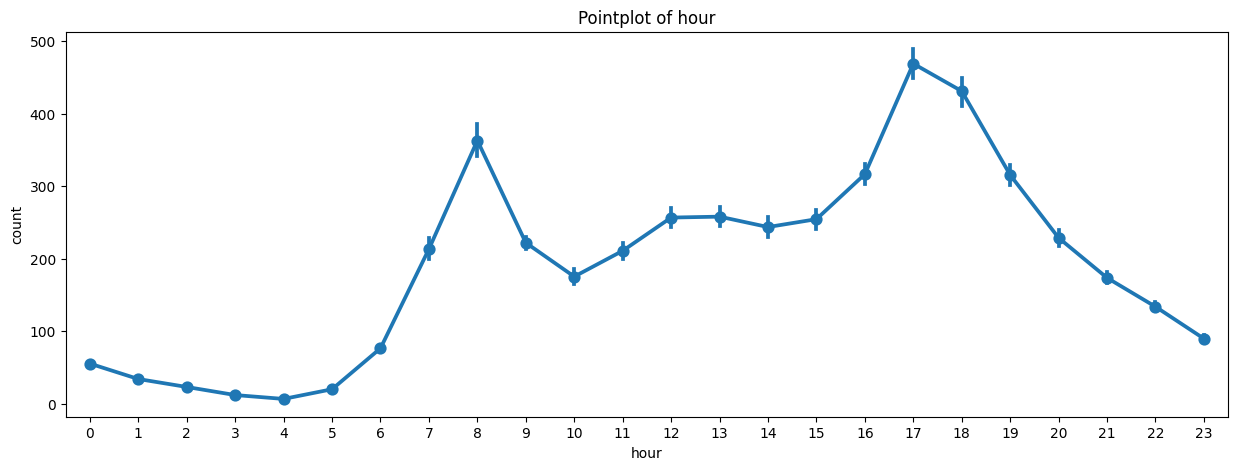

In [ ]:
plt.figure(figsize=(15, 5))
sns.pointplot(x='hour', y='count', data=df)
plt.title('Pointplot of hour')
plt.show()

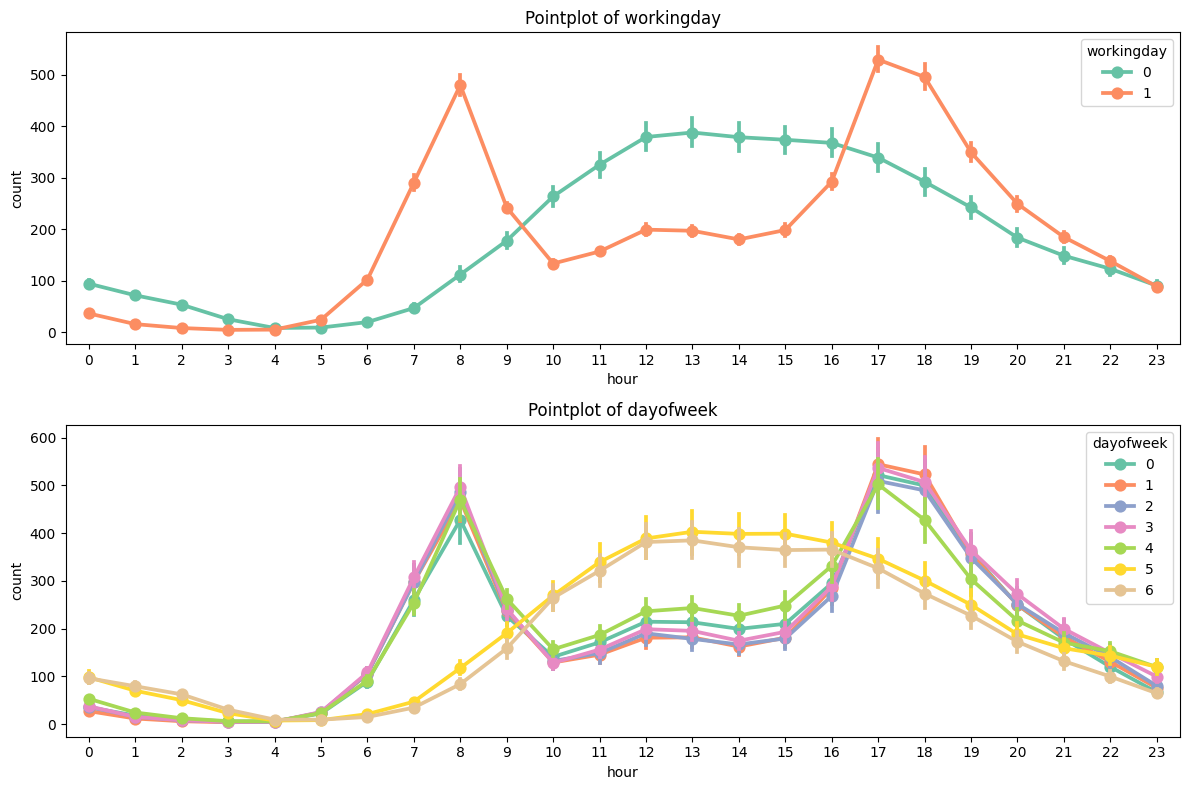

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.pointplot(x='hour', y='count', hue='workingday', data=df, ax=axes[0], palette="Set2")
axes[0].set_title('Pointplot of workingday')
sns.pointplot(x='hour', y='count', hue='dayofweek', data=df, ax=axes[1], palette="Set2")
axes[1].set_title('Pointplot of dayofweek')

plt.tight_layout()
plt.show()

__중요하다.__

평일은 5-8시, 15-17시에 급증했다.

주말은 7-13시 까지 증가했다.

### 날씨 와 계절에 따른 자전거 이용객 수

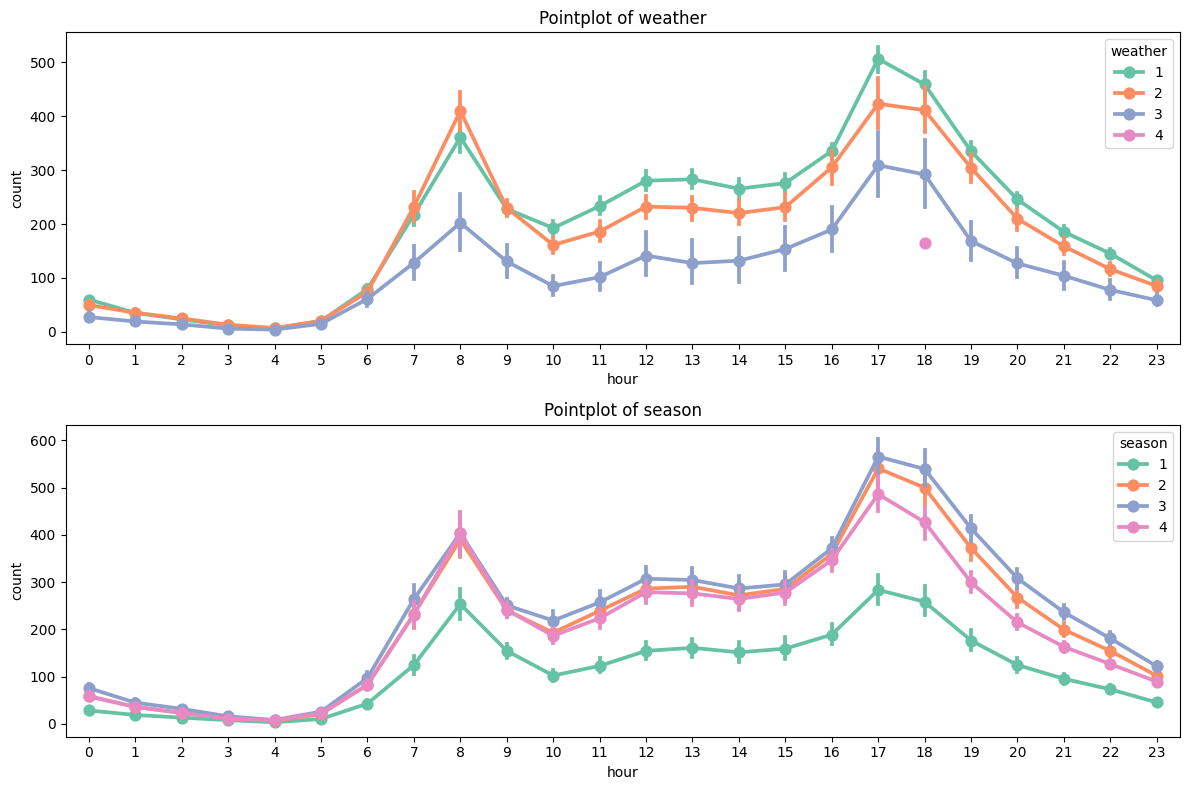

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.pointplot(x='hour', y='count', hue='weather', data=df, ax=axes[0], palette="Set2")
axes[0].set_title('Pointplot of weather')
sns.pointplot(x='hour', y='count', hue='season', data=df, ax=axes[1], palette="Set2")
axes[1].set_title('Pointplot of season')
plt.tight_layout()
plt.show()

날씨가 안좋으면 자전거를 많이 안빌린다.

계절도 온도가 낮은 봄(1-3월)에는 대여량이 조금 낮다.

# 초기 모델 제작

In [ ]:
# 변수 지정
X = df.drop('count', axis=1)
y = df['count']

# 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_log_error
# rmsle = np.sqrt(mean_squared_log_error(y_test, pred))
# print(f"RMSLE: {rmsle:.4f}")

"""
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
/tmp/ipython-input-24-2709364342.py in <cell line: 0>()
      1 from sklearn.metrics import mean_squared_log_error
----> 2 rmsle = np.sqrt(mean_squared_log_error(y_test, pred))
      3 print(f"RMSLE: {rmsle:.4f}")

1 frames
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py in mean_squared_log_error(y_true, y_pred, sample_weight, multioutput)
    744
    745     if xp.any(y_true <= -1) or xp.any(y_pred <= -1):
--> 746         raise ValueError(
    747             "Mean Squared Logarithmic Error cannot be used when "
    748             "targets contain values less than or equal to -1."

ValueError: Mean Squared Logarithmic Error cannot be used when targets contain values less than or equal to -1.
"""

'\n---------------------------------------------------------------------------\nValueError                                Traceback (most recent call last)\n/tmp/ipython-input-24-2709364342.py in <cell line: 0>()\n      1 from sklearn.metrics import mean_squared_log_error\n----> 2 rmsle = np.sqrt(mean_squared_log_error(y_test, pred))\n      3 print(f"RMSLE: {rmsle:.4f}")\n\n1 frames\n/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py in mean_squared_log_error(y_true, y_pred, sample_weight, multioutput)\n    744\n    745     if xp.any(y_true <= -1) or xp.any(y_pred <= -1):\n--> 746         raise ValueError(\n    747             "Mean Squared Logarithmic Error cannot be used when "\n    748             "targets contain values less than or equal to -1."\n\nValueError: Mean Squared Logarithmic Error cannot be used when targets contain values less than or equal to -1.\n'

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
MAE = mean_absolute_error(y_test, pred)
MSE = mean_squared_error(y_test, pred)
RMSE = np.sqrt(MSE)

print(f"MAE: {MAE:.4f}")
print(f"MSE: {MSE:.4f}")
print(f"RMSE: {RMSE:.4f}")

MAE: 105.6495
MSE: 19954.8300
RMSE: 141.2616


음수가 들어가 있는 것 같다. 데이터 처리가 필요해 보인다.

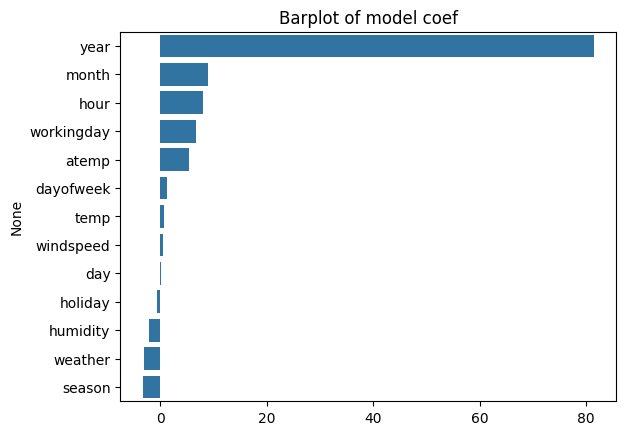

In [ ]:
coef = pd.Series(model.coef_, index = X.columns)
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)
plt.title('Barplot of model coef')
plt.show()

값이 클 수록 target에 더 많은 영향을 준다

# Features Engineering

위에서 확인 했을 때 데이터 가공이 필요한 부분들이다.
 - target데이터 로그변환(왜도 개선)
 - windspeed 이상치 제거
 - 추가적으로 평일, 휴일 모두 6-8시까지 이용객이 늘어나니 파생변수를 만들겠다.

먼저 데이터 처리만 하고 점수를 계산해보자.

## 이상치 처리

In [ ]:
df_cut = df.copy()

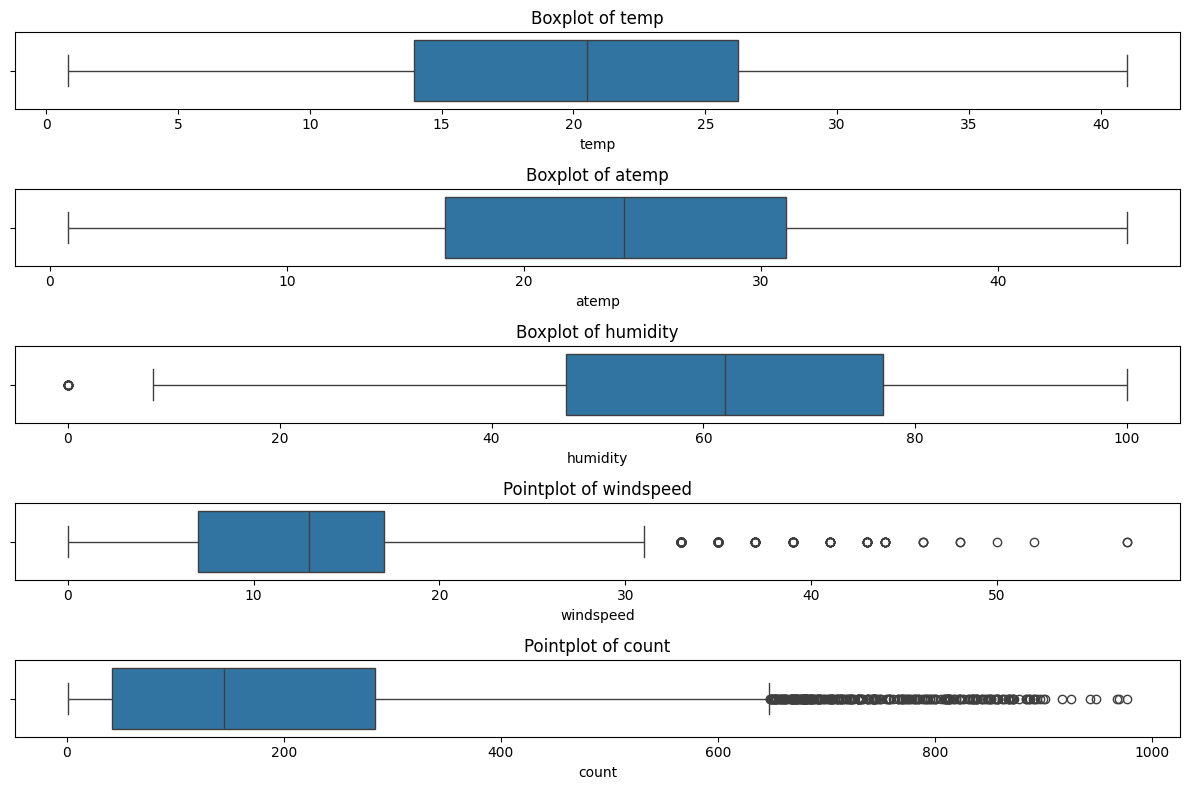

In [ ]:
fig, axes = plt.subplots(5, 1, figsize = (12, 8))

sns.boxplot(data = df_cut, x="temp", ax=axes[0])
axes[0].set_title('Boxplot of temp')
sns.boxplot(data = df_cut, x="atemp", ax=axes[1])
axes[1].set_title('Boxplot of atemp')
sns.boxplot(data = df_cut, x="humidity", ax=axes[2])
axes[2].set_title('Boxplot of humidity')
sns.boxplot(data = df_cut, x="windspeed", ax=axes[3])
axes[3].set_title('Pointplot of windspeed')
sns.boxplot(data = df_cut, x="count", ax=axes[4])
axes[4].set_title('Pointplot of count')
plt.tight_layout()
plt.show()

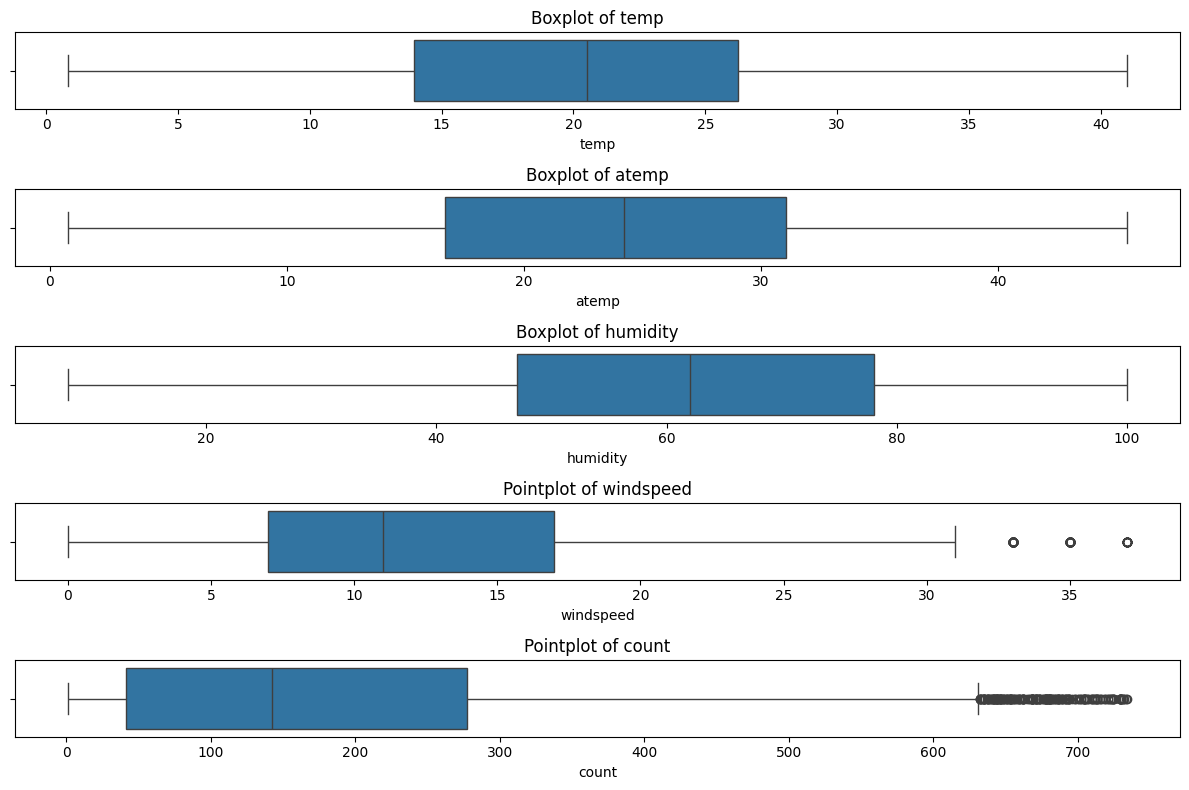

(10652, 14)
(10652, 14)


In [ ]:
# 이상치 제거
cols = ['humidity', 'windspeed', 'count']   # temp, atemp는 이상치가 없다
for col in cols:
    df_cut = df_cut[np.abs(df_cut[col] - df_cut[col].mean()) <= (3*df_cut[col].std())]

fig, axes = plt.subplots(5, 1, figsize = (12, 8))

sns.boxplot(data = df_cut, x="temp", ax=axes[0])
axes[0].set_title('Boxplot of temp')
sns.boxplot(data = df_cut, x="atemp", ax=axes[1])
axes[1].set_title('Boxplot of atemp')
sns.boxplot(data = df_cut, x="humidity", ax=axes[2])
axes[2].set_title('Boxplot of humidity')
sns.boxplot(data = df_cut, x="windspeed", ax=axes[3])
axes[3].set_title('Pointplot of windspeed')
sns.boxplot(data = df_cut, x="count", ax=axes[4])
axes[4].set_title('Pointplot of count')
plt.tight_layout()
plt.show()

print(df_cut.shape)  #(10886, 12) 변경 전
print(df_cut.shape)  #(10212, 20) 변경 후

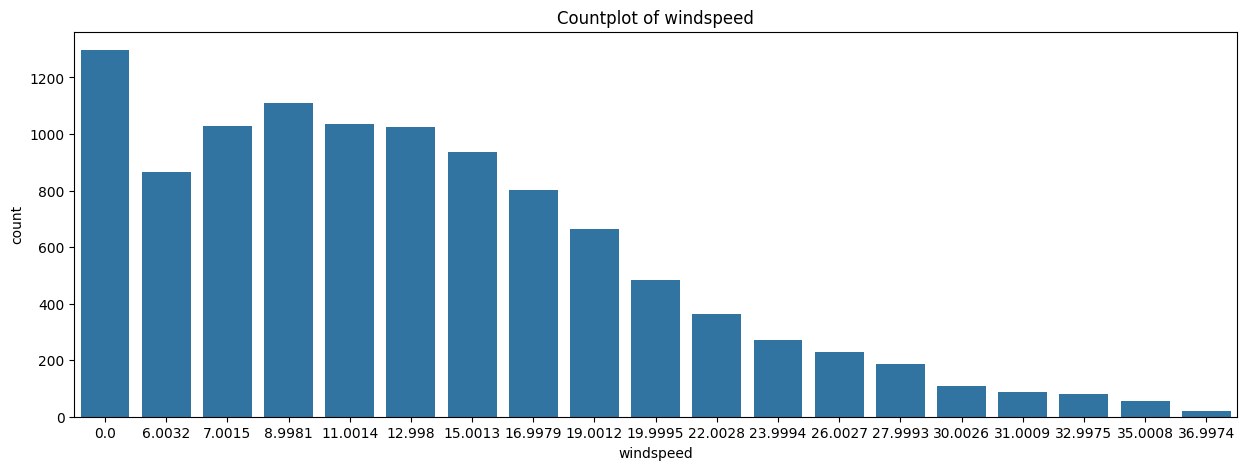

In [ ]:
# windspeed 확인
plt.figure(figsize=(15, 5))
sns.countplot(data = df_cut, x='windspeed')
plt.title('Countplot of windspeed')
plt.show()

분포가 처음보다 나아졌다

## 로그변환

((array([-3.82619387, -3.60190625, -3.4788108 , ...,  3.4788108 ,
          3.60190625,  3.82619387]),
  array([0.69314718, 0.69314718, 0.69314718, ..., 6.5971457 , 6.59850903,
         6.5998705 ])),
 (np.float64(1.347851420820821),
  np.float64(4.5657965674829555),
  np.float64(0.9579552474430569)))

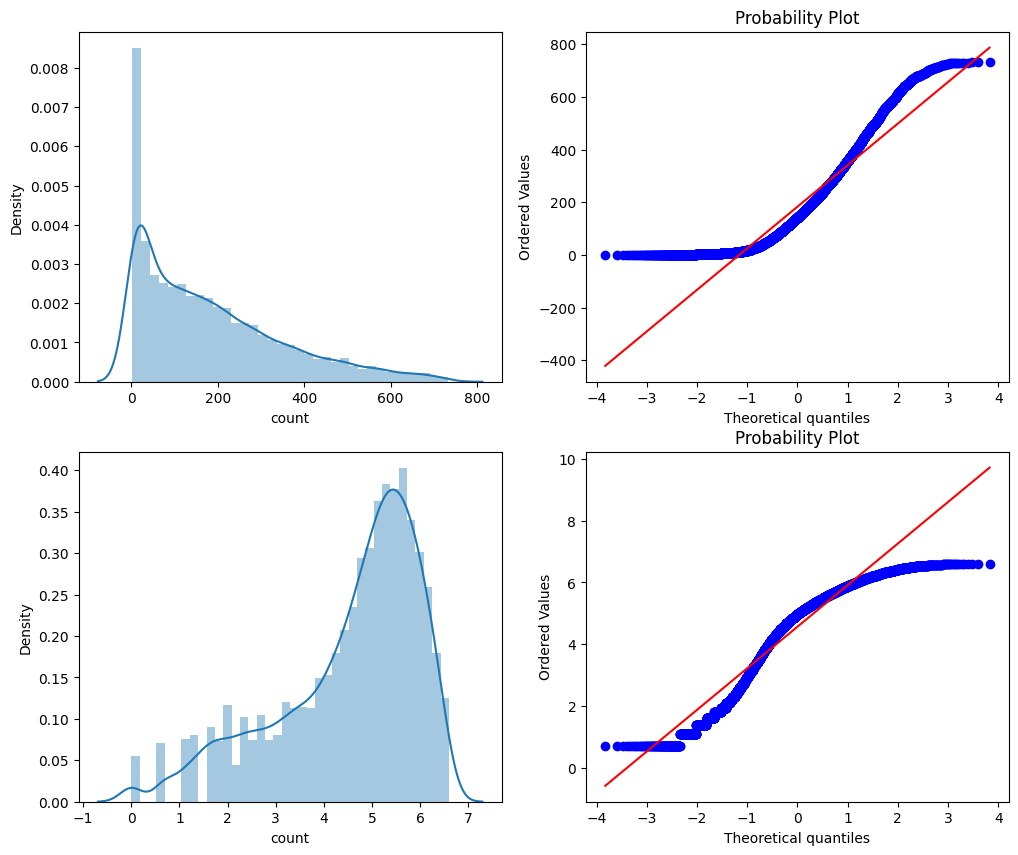

In [ ]:
from scipy import stats
import warnings
warnings.filterwarnings(action='ignore')
# count 값의 데이터 분포 파악
figure, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.distplot(df_cut['count'], ax=axes[0][0])
stats.probplot(df_cut['count'], dist='norm', fit=True, plot=axes[0][1])
# 로그 변환 시 데이터 분포
sns.distplot(np.log(df_cut['count']), ax=axes[1][0])
stats.probplot(np.log1p(df_cut['count']), dist='norm', fit=True, plot=axes[1][1])

정규화를 해주었다

In [ ]:
# 변수 지정
X = df_cut.drop('count', axis=1)
y = df_cut['count']

y = np.log(y)

# 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)


In [ ]:
pred = np.exp(pred)
y_test = np.exp(y_test)


In [ ]:
rmsle = np.sqrt(mean_squared_log_error(y_test, pred))
print(f"RMSLE: {rmsle:.4f}")

RMSLE: 1.0094


In [ ]:
MAE = mean_absolute_error(y_test, pred)
MSE = mean_squared_error(y_test, pred)
RMSE = np.sqrt(MSE)

print(f"MAE: {MAE:.4f}")
print(f"MSE: {MSE:.4f}")
print(f"RMSE: {RMSE:.4f}")

MAE: 102.0558
MSE: 23207.1067
RMSE: 152.3388


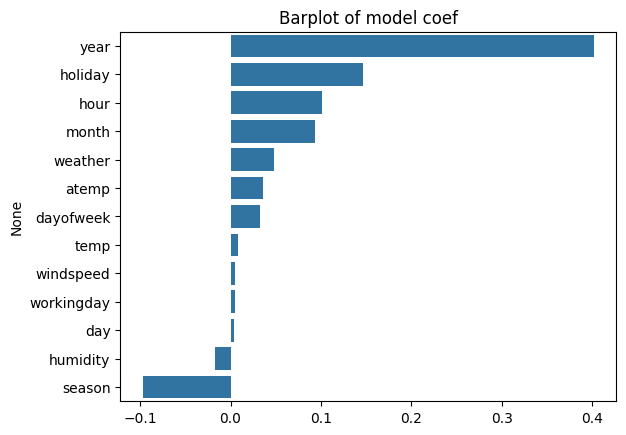

In [ ]:
coef = pd.Series(model.coef_, index = X.columns)
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)
plt.title('Barplot of model coef')
plt.show()

## 계절데이터 범위 수정

In [ ]:
df_season = df_cut.copy()

In [ ]:
df_season.head()

,year,month,day,hour,dayofweek,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011,1,1,0,5,1,0,0,1,9.84,14.395,81,0.0,16
1,2011,1,1,1,5,1,0,0,1,9.02,13.635,80,0.0,40
2,2011,1,1,2,5,1,0,0,1,9.02,13.635,80,0.0,32
3,2011,1,1,3,5,1,0,0,1,9.84,14.395,75,0.0,13
4,2011,1,1,4,5,1,0,0,1,9.84,14.395,75,0.0,1


In [ ]:
def assign_season(month):
    if month in [3, 4, 5]:
        return 1
    elif month in [6, 7, 8]:
        return 2
    elif month in [9, 10, 11]:
        return 3
    else:
        return 4

In [ ]:
df_season['season'] = df_season['month'].apply(assign_season)

In [ ]:
pd.crosstab(df_season['season'], df_season['month'])

month,1,2,3,4,5,6,7,8,9,10,11,12
season,,,,,,,,,,,,
1,0,0,864,890,898,0,0,0,0,0,0,0
2,0,0,0,0,0,894,893,887,0,0,0,0
3,0,0,0,0,0,0,0,0,874,877,910,0
4,879,878,0,0,0,0,0,0,0,0,0,908


In [ ]:
# 변수 지정
X = df_season.drop('count', axis=1)
y = df_season['count']

y = np.log(y)

# 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

In [ ]:
pred = np.exp(pred)
y_test = np.exp(y_test)

In [ ]:
rmsle = np.sqrt(mean_squared_log_error(y_test, pred))
print(f"RMSLE: {rmsle:.4f}")

RMSLE: 1.0094


In [ ]:
MAE = mean_absolute_error(y_test, pred)
MSE = mean_squared_error(y_test, pred)
RMSE = np.sqrt(MSE)

print(f"MAE: {MAE:.4f}")
print(f"MSE: {MSE:.4f}")
print(f"RMSE: {RMSE:.4f}")

MAE: 102.2232
MSE: 23308.0576
RMSE: 152.6698


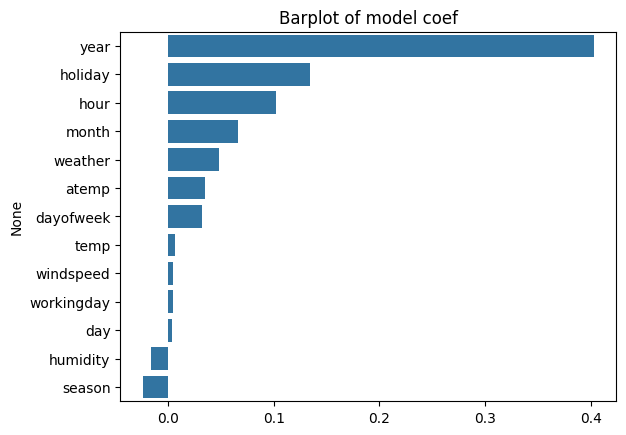

In [ ]:
coef = pd.Series(model.coef_, index = X.columns)
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)
plt.title('Barplot of model coef')
plt.show()

## 파생변수 생성

In [ ]:
df_hot = df_season.copy()

In [ ]:
df_hot.head()

,year,month,day,hour,dayofweek,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011,1,1,0,5,4,0,0,1,9.84,14.395,81,0.0,16
1,2011,1,1,1,5,4,0,0,1,9.02,13.635,80,0.0,40
2,2011,1,1,2,5,4,0,0,1,9.02,13.635,80,0.0,32
3,2011,1,1,3,5,4,0,0,1,9.84,14.395,75,0.0,13
4,2011,1,1,4,5,4,0,0,1,9.84,14.395,75,0.0,1


In [ ]:
df_hot['is_hottime'] = df_hot['hour'].apply(lambda x: 1 if x in [6, 8] else 0)

In [ ]:
df_hot

,year,month,day,hour,dayofweek,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,is_hottime
0,2011,1,1,0,5,4,0,0,1,9.84,14.395,81,0.0000,16,0
1,2011,1,1,1,5,4,0,0,1,9.02,13.635,80,0.0000,40,0
2,2011,1,1,2,5,4,0,0,1,9.02,13.635,80,0.0000,32,0
3,2011,1,1,3,5,4,0,0,1,9.84,14.395,75,0.0000,13,0
4,2011,1,1,4,5,4,0,0,1,9.84,14.395,75,0.0000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012,12,19,19,2,4,0,1,1,15.58,19.695,50,26.0027,336,0
10882,2012,12,19,20,2,4,0,1,1,14.76,17.425,57,15.0013,241,0
10883,2012,12,19,21,2,4,0,1,1,13.94,15.910,61,15.0013,168,0
10884,2012,12,19,22,2,4,0,1,1,13.94,17.425,61,6.0032,129,0


In [ ]:
df_hot['is_hottime'].value_counts()

,count
is_hottime,
0,9766
1,886


잘 적용 된 것 같다

In [ ]:
# 변수 지정
X = df_hot.drop('count', axis=1)
y = df_hot['count']

y = np.log(y)

# 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

pred = np.exp(pred)
y_test = np.exp(y_test)

rmsle = np.sqrt(mean_squared_log_error(y_test, pred))
print(f"RMSLE: {rmsle:.4f}")

RMSLE: 0.9762


점수가 조금 더 낮아졌다.

In [ ]:
MAE = mean_absolute_error(y_test, pred)
MSE = mean_squared_error(y_test, pred)
RMSE = np.sqrt(MSE)

print(f"MAE: {MAE:.4f}")
print(f"MSE: {MSE:.4f}")
print(f"RMSE: {RMSE:.4f}")

MAE: 101.7102
MSE: 22303.9745
RMSE: 149.3452


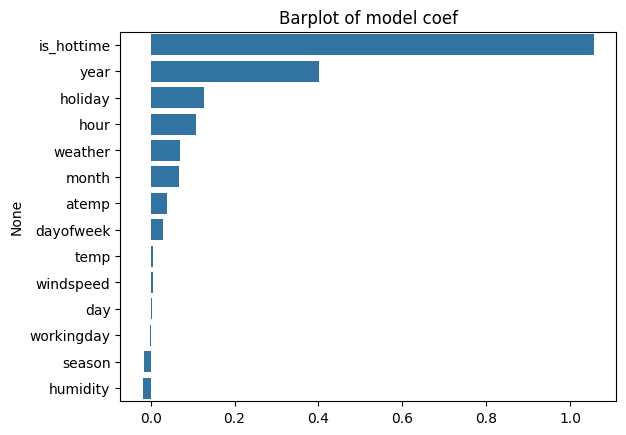

In [ ]:
coef = pd.Series(model.coef_, index = X.columns)
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)
plt.title('Barplot of model coef')
plt.show()

# 결과: RMSLE: 0.9762

값이 클 수록 target에 더 많은 영향을 준다
 - 집중 이용시간은 이용건수에 영향을 준다.
 - 년도 역시 영향을 주며 실제 11년도 12년도 이용율 차이가 있었다.
 - 기타 시간, 월, 날씨가 영향을 준다.
하위 두개의 feature는 target과 음의 관계를 갖는다, 즉 값이 커질 수록 target은 줄어든다.
 - 습도는 높을 수록 사람들이 이용을 잘 안하게 된다.
 - 계절도 추운계절일수록 이용을 안하게 된다.

# test데이터 적용

In [ ]:
test = pd.read_csv('/content/drive/MyDrive/codeit/data/미션3/test.csv')

In [ ]:
test['datetime'] = pd.to_datetime(test['datetime'])
# 날짜데이터 파생변수로 분리
test['year'] = test.datetime.apply(lambda x : x.year)
test['month'] = test.datetime.apply(lambda x : x.month)
test['day'] = test.datetime.apply(lambda x : x.day)
test['hour'] = test.datetime.apply(lambda x : x.hour)
test['dayofweek'] = test['datetime'].dt.dayofweek
test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,dayofweek
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1,3
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,2,3
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,3
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,4,3


In [ ]:
test = test.drop('datetime', axis=1)
test = test[['year', 'month', 'day', 'hour', 'dayofweek', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']]


In [ ]:
test.loc[test['windspeed'] == 0, 'windspeed'] = test['windspeed'].mean()

In [ ]:
test['is_hottime'] = test['hour'].apply(lambda x: 1 if x in [6, 8] else 0)

In [ ]:
predictions = model.predict(test)

predictions = np.maximum(0, np.exp(predictions))
print(predictions[:10])

[10.11148956 11.47167476 12.77469226 13.71124748 15.26864828 15.11990281
 46.81573807 19.89827115 65.0462617  28.97133752]


In [ ]:
# Add the predictions to a new column in the test DataFrame
test['predict'] = predictions

# Display the first few rows of the updated test DataFrame
display(test.head())

,year,month,day,hour,dayofweek,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,is_hottime,predict
0,2011,1,20,0,3,1,0,1,1,10.66,11.365,56,26.002700,0,10.111490
1,2011,1,20,1,3,1,0,1,1,10.66,13.635,56,12.631157,0,11.471675
2,2011,1,20,2,3,1,0,1,1,10.66,13.635,56,12.631157,0,12.774692
3,2011,1,20,3,3,1,0,1,1,10.66,12.880,56,11.001400,0,13.711247
4,2011,1,20,4,3,1,0,1,1,10.66,12.880,56,11.001400,0,15.268648


In [ ]:
# Save the updated test DataFrame to a new CSV file
test.to_csv('/content/drive/MyDrive/codeit/data/미션3/test_with_predictions.csv', index=False)